In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("birds.csv")

# Basic cleaning
df["OBSERVATION DATE"] = pd.to_datetime(df["OBSERVATION DATE"])
df["LAST EDITED DATE"] = pd.to_datetime(df["LAST EDITED DATE"], errors="coerce")
df["OBS COUNT NUM"] = pd.to_numeric(df["OBSERVATION COUNT"], errors="coerce")

# Month fields for plotting
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df["MONTH NUM"] = df["OBSERVATION DATE"].dt.month
df["MONTH"] = pd.Categorical(
    df["OBSERVATION DATE"].dt.strftime("%b"),
    categories=month_order,
    ordered=True
)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (308370, 18)

Columns:
['GLOBAL UNIQUE IDENTIFIER', 'LAST EDITED DATE', 'COMMON NAME', 'SCIENTIFIC NAME', 'OBSERVATION COUNT', 'COUNTY', 'LOCALITY', 'LATITUDE', 'LONGITUDE', 'IBA CODE', 'IBA NAME', 'OBSERVATION DATE', 'TIME OBSERVATIONS STARTED', 'DURATION MINUTES', 'OBSERVER ID', 'OBS COUNT NUM', 'MONTH NUM', 'MONTH']


In [2]:
# Province-wide monthly summary
overall_month = (
    df.groupby(["MONTH NUM", "MONTH"], observed=True)
      .agg(
          observation_records=("GLOBAL UNIQUE IDENTIFIER", "count"),
          species_richness=("COMMON NAME", "nunique")
      )
      .reset_index()
      .sort_values("MONTH NUM")
)

print("Province-wide monthly summary:")
print(overall_month)

# Selected local hotspots near the Geo Centre
hotspots = [
    "St. John's--Geo Centre trails",
    "St. John's--Quidi Vidi Lake",
    "St. John's--Virginia Lake",
    "NL--Cape Spear",
]

label_map = {
    "St. John's--Geo Centre trails": "Geo Centre trails",
    "St. John's--Quidi Vidi Lake": "Quidi Vidi Lake",
    "St. John's--Virginia Lake": "Virginia Lake",
    "NL--Cape Spear": "Cape Spear",
}

hotspot_summary = (
    df[df["LOCALITY"].isin(hotspots)]
    .groupby("LOCALITY")
    .agg(
        observation_records=("GLOBAL UNIQUE IDENTIFIER", "count"),
        species_richness=("COMMON NAME", "nunique"),
        latitude=("LATITUDE", "median"),
        longitude=("LONGITUDE", "median")
    )
    .reset_index()
)

hotspot_summary["label"] = hotspot_summary["LOCALITY"].map(label_map)

print("\nSelected hotspot summary:")
print(hotspot_summary.sort_values("observation_records", ascending=False))

# Monthly hotspot species richness
monthly_hotspots = (
    df[df["LOCALITY"].isin(hotspots)]
    .groupby(["LOCALITY", "MONTH NUM", "MONTH"], observed=True)
    .agg(species_richness=("COMMON NAME", "nunique"))
    .reset_index()
    .sort_values(["LOCALITY", "MONTH NUM"])
)

print("\nMonthly species richness at selected hotspots:")
print(
    monthly_hotspots
    .pivot(index="MONTH", columns="LOCALITY", values="species_richness")
    .reindex(month_order)
)

Province-wide monthly summary:
    MONTH NUM MONTH  observation_records  species_richness
0           1   Jan                13341               127
1           2   Feb                 8070               113
2           3   Mar                 8498               113
3           4   Apr                12495               138
4           5   May                34215               211
5           6   Jun                68284               209
6           7   Jul                64881               207
7           8   Aug                30892               194
8           9   Sep                27926               218
9          10   Oct                16694               205
10         11   Nov                11594               188
11         12   Dec                11480               144

Selected hotspot summary:
                        LOCALITY  observation_records  species_richness  \
2    St. John's--Quidi Vidi Lake                 6923                82   
3      St. John's--Virgin

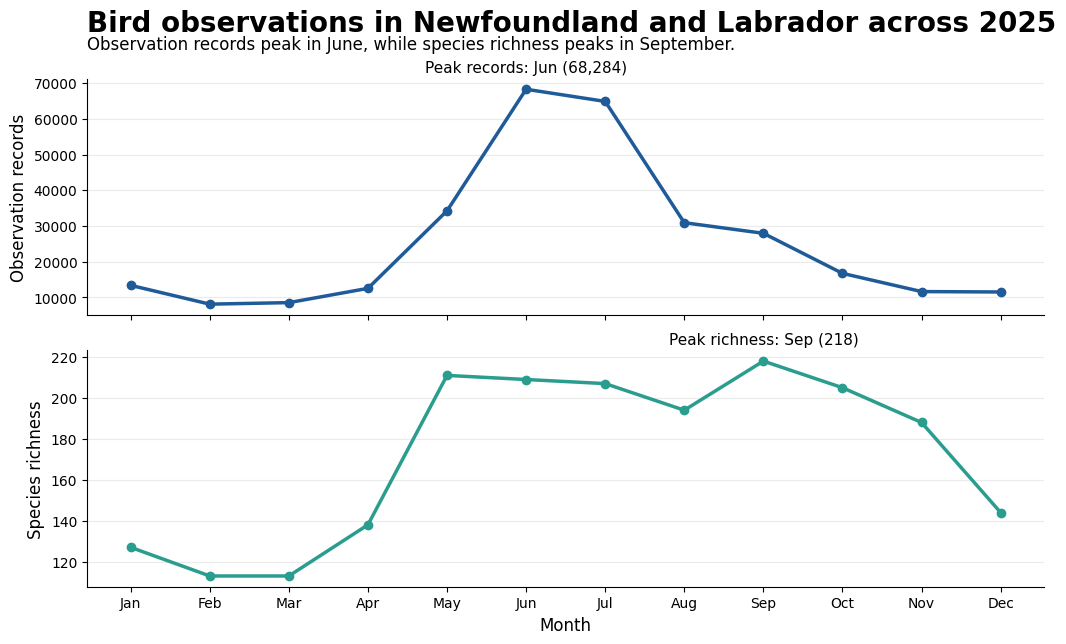

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True)
fig.subplots_adjust(top=0.87, hspace=0.15, left=0.10, right=0.97, bottom=0.10)

records_color = "#1f5a99"
richness_color = "#2a9d8f"

# Use fig.text for both title and subtitle so they are truly left-aligned
fig.text(
    0.10, 0.975,
    "Bird observations in Newfoundland and Labrador across 2025",
    ha="left", va="top", fontsize=20, fontweight="bold"
)
fig.text(
    0.10, 0.935,
    "Observation records peak in June, while species richness peaks in September.",
    ha="left", va="top", fontsize=12
)

# Top panel
axes[0].plot(
    overall_month["MONTH"],
    overall_month["observation_records"],
    marker="o",
    linewidth=2.5,
    color=records_color
)
axes[0].set_ylabel("Observation records", fontsize=12)
axes[0].grid(True, axis="y", alpha=0.25)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

peak_records = overall_month.loc[overall_month["observation_records"].idxmax()]
axes[0].annotate(
    f"Peak records: {peak_records['MONTH']} ({peak_records['observation_records']:,})",
    xy=(peak_records["MONTH"], peak_records["observation_records"]),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85)
)

# Bottom panel
axes[1].plot(
    overall_month["MONTH"],
    overall_month["species_richness"],
    marker="o",
    linewidth=2.5,
    color=richness_color
)
axes[1].set_ylabel("Species richness", fontsize=12)
axes[1].set_xlabel("Month", fontsize=12)
axes[1].grid(True, axis="y", alpha=0.25)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

peak_species = overall_month.loc[overall_month["species_richness"].idxmax()]
axes[1].annotate(
    f"Peak richness: {peak_species['MONTH']} ({peak_species['species_richness']})",
    xy=(peak_species["MONTH"], peak_species["species_richness"]),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85)
)

plt.savefig("proposal_vis_1_province_seasonality_final.png", dpi=300, bbox_inches="tight")
plt.show()

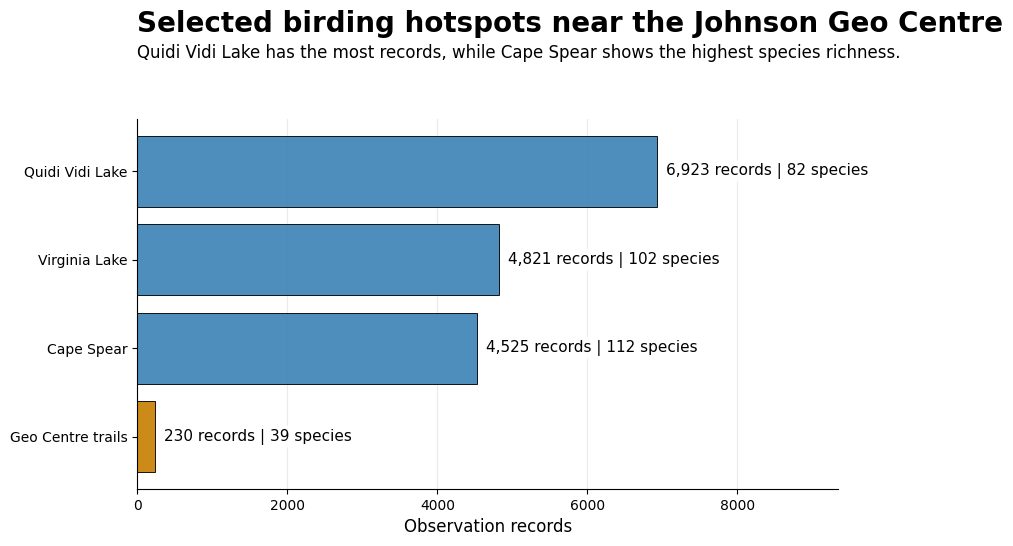

In [23]:
import matplotlib.pyplot as plt

plot_df = (
    hotspot_summary[["label", "observation_records", "species_richness"]]
    .sort_values("observation_records", ascending=True)
    .copy()
)

colors = [
    "#c77d00" if label == "Geo Centre trails" else "#3b82b6"
    for label in plot_df["label"]
]

fig, ax = plt.subplots(figsize=(9.6, 5.6))
fig.subplots_adjust(top=0.78, left=0.23, right=0.96, bottom=0.12)

fig.text(
    0.23, 0.975,
    "Selected birding hotspots near the Johnson Geo Centre",
    ha="left", va="top", fontsize=20, fontweight="bold"
)
fig.text(
    0.23, 0.915,
    "Quidi Vidi Lake has the most records, while Cape Spear shows the highest species richness.",
    ha="left", va="top", fontsize=12
)

bars = ax.barh(
    plot_df["label"],
    plot_df["observation_records"],
    color=colors,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.9
)

# Annotate each bar with records + species richness
for bar, records, richness in zip(
    bars, plot_df["observation_records"], plot_df["species_richness"]
):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        x + 120,
        y,
        f"{records:,} records | {richness} species",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9)
    )

ax.set_xlabel("Observation records", fontsize=12)
ax.set_ylabel("")
ax.grid(True, axis="x", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Give space for annotations on the right
ax.set_xlim(0, plot_df["observation_records"].max() * 1.35)

plt.savefig("proposal_vis_2_hotspot_comparison_final.png", dpi=300, bbox_inches="tight")
plt.show()

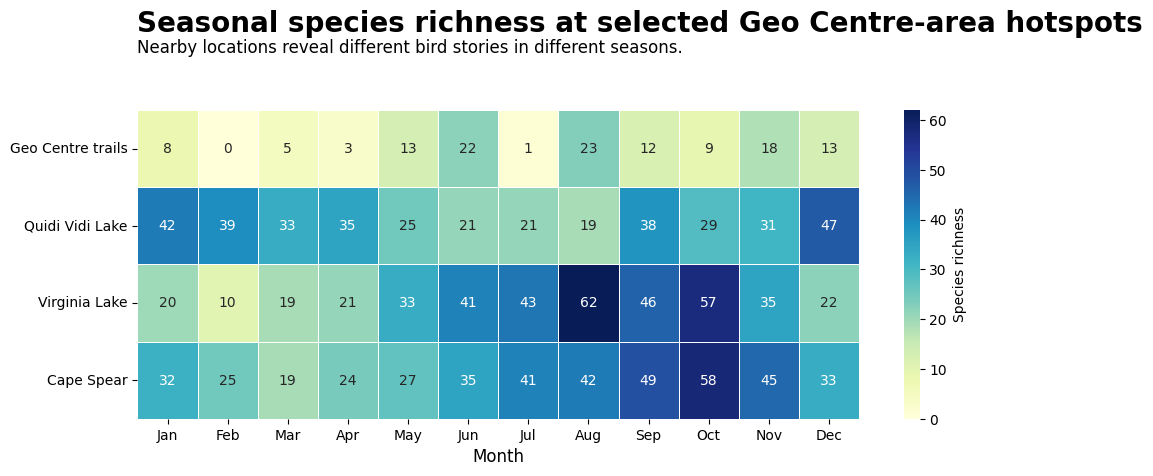

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

heat = monthly_hotspots.copy()
heat["label"] = heat["LOCALITY"].map(label_map)
heat["MONTH"] = pd.Categorical(heat["MONTH"], categories=month_order, ordered=True)

heat = (
    heat.pivot(index="label", columns="MONTH", values="species_richness")
    .reindex(["Geo Centre trails", "Quidi Vidi Lake", "Virginia Lake", "Cape Spear"])
    .reindex(columns=month_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(11, 4.9))
fig.subplots_adjust(top=0.77, left=0.15, right=0.97, bottom=0.14)

fig.text(
    0.15, 0.975,
    "Seasonal species richness at selected Geo Centre-area hotspots",
    ha="left", va="top", fontsize=20, fontweight="bold"
)
fig.text(
    0.15, 0.915,
    "Nearby locations reveal different bird stories in different seasons.",
    ha="left", va="top", fontsize=12
)

sns.heatmap(
    heat,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Species richness"},
    ax=ax
)

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.savefig("proposal_vis_3_hotspot_heatmap_final.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# Best months province-wide
best_records_month = overall_month.loc[overall_month["observation_records"].idxmax()]
best_species_month = overall_month.loc[overall_month["species_richness"].idxmax()]

print("Highest province-wide observation records:")
print(best_records_month[["MONTH", "observation_records"]])

print("\nHighest province-wide species richness:")
print(best_species_month[["MONTH", "species_richness"]])

# Hotspot totals
print("\nSelected hotspot totals:")
print(
    hotspot_summary[["label", "observation_records", "species_richness"]]
    .sort_values("observation_records", ascending=False)
)

Highest province-wide observation records:
MONTH                    Jun
observation_records    68284
Name: 5, dtype: object

Highest province-wide species richness:
MONTH               Sep
species_richness    218
Name: 8, dtype: object

Selected hotspot totals:
               label  observation_records  species_richness
2    Quidi Vidi Lake                 6923                82
3      Virginia Lake                 4821               102
0         Cape Spear                 4525               112
1  Geo Centre trails                  230                39
